In [48]:
import os 
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (10, 10)


In [3]:
pth = Path('../..').resolve() / 'outputs'
pth

PosixPath('/mnt/d/science/summer-wsi/outputs')

In [20]:
f = "model_vec.lemma_config.ru.lemmas_similarity_threshold=1.0,model_vec.lemma_config.ru.lemmatizer_name=snowball,model_vec=subst_ru_multimask"
s = {}
for param, pattern in params.items():
    value = re.search(pattern, str(f))
    if value:
        s[param] = value[0]
s

{'cfg': '_ru_multimask',
 'levenshtein_threshold': '1.0',
 'lemmatizer': 'snowball'}

In [45]:
metrics = ['max_ARI', 'calinski_harabasz_ARI', 'silhouette_ARI']
datasets = {
    'russe_bts-rnc-ru-_train': 'russe_train',
    'xl_wsd-multilang-dev': 'xlwsd_multi_dev',
    'russe_bts-rnc-trainonly-ru-_train': 'russe_train'
}
d = []
params = {
    # 'dataset': '(?<=runname=)\w+',
    'cfg': r'(?<=model_vec=subst).*',
    'levenshtein_threshold': r'(?<=threshold=)\d.\d',
    'lemmatizer': '(?<=lemmatizer_name=)\w+'
}
d = []
for f in pth.glob('*/*similarity_threshold*rombek*'):
    s = {}
    for param, pattern in params.items():
        value = re.search(pattern, str(f))
        if value:
            s[param] = value[0]
    for metric in metrics:
        pth2 = f / 'VectorizingPipeline' / 'agg_metrics' / f"{metric}.tsv"
        if pth2.is_file():
            score = pd.read_csv(pth2, sep='\t')
            score = score[score.part.isin(datasets.keys())]
            score['metric'] = metric
            for k, v in s.items():
                score[k] = v
            d.append(score)

df0 = pd.concat(d)
df0['part'] = df0['part'].replace(datasets)
# df0 = pd.DataFrame(d, columns=list(params.keys()) + ['metric', 'value'])
df = df0.drop_duplicates(subset=list(params.keys()) + ['part', 'metric'], keep='last')
df = df.apply(pd.to_numeric, errors='coerce').fillna(df)
if df.shape[0] != df0.shape[0]:
    print(f'found {df.shape[0] - df0.shape[0]} duplicates')
df

found -99 duplicates


,metric,score,hypers,part,cfg,levenshtein_threshold,lemmatizer
0,max_ARI,76.358709,NaN,russe_train,_rombek,0.7,pymorphy
0,calinski_harabasz_ARI,44.216418,NaN,russe_train,_rombek,0.7,pymorphy
0,silhouette_ARI,54.046024,NaN,russe_train,_rombek,0.7,pymorphy
0,max_ARI,74.818678,NaN,russe_train,_rombek,0.7,snowball
0,calinski_harabasz_ARI,41.762134,NaN,russe_train,_rombek,0.7,snowball
...,...,...,...,...,...,...,...
0,calinski_harabasz_ARI,9.227341,NaN,xlwsd_multi_dev,_rombek,1.0,none
0,silhouette_ARI,7.680616,NaN,xlwsd_multi_dev,_rombek,1.0,none
0,max_ARI,37.349005,NaN,xlwsd_multi_dev,_rombek,1.0,stanza
0,calinski_harabasz_ARI,11.939049,NaN,xlwsd_multi_dev,_rombek,1.0,stanza


('max_ARI', 'russe_train')
('max_ARI', 'xlwsd_multi_dev')
('calinski_harabasz_ARI', 'russe_train')
('calinski_harabasz_ARI', 'xlwsd_multi_dev')
('silhouette_ARI', 'russe_train')
('silhouette_ARI', 'xlwsd_multi_dev')


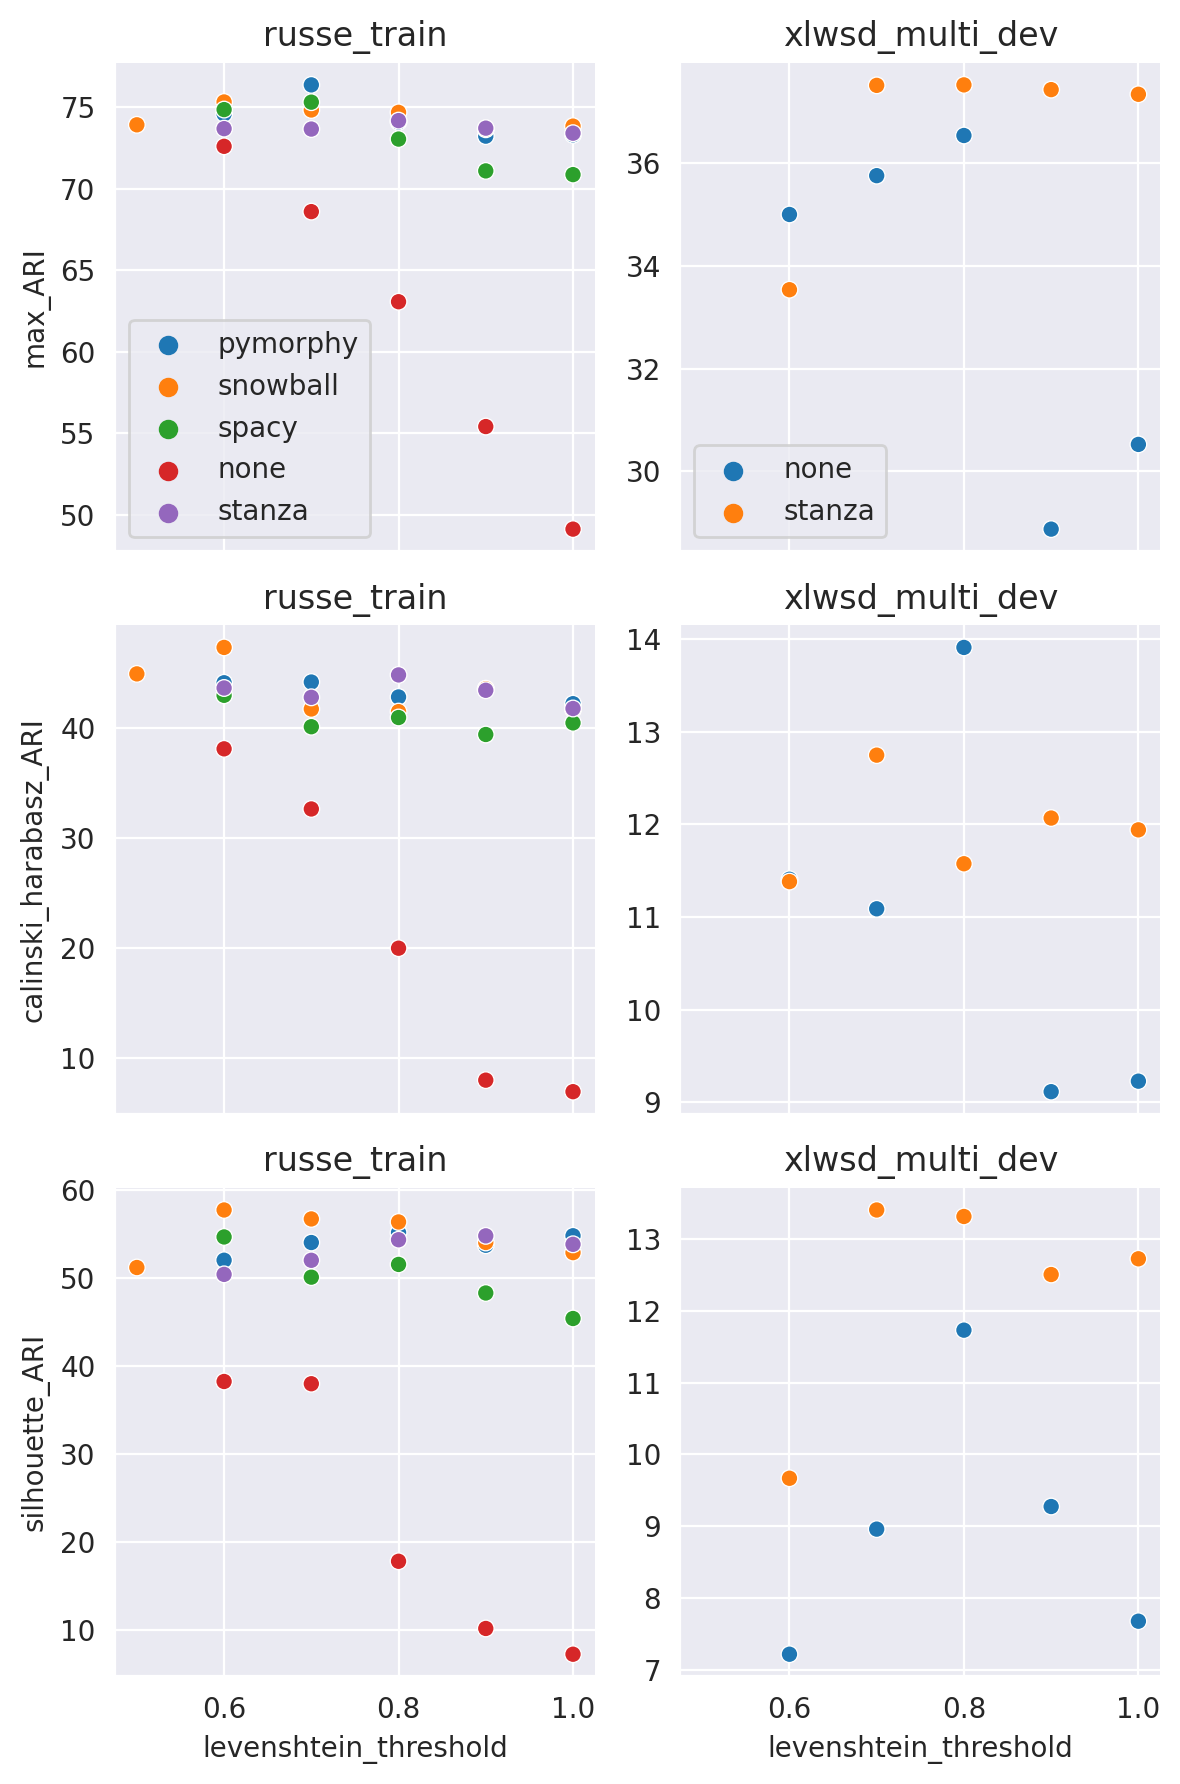

In [50]:

g = sns.FacetGrid(df, col='part', row='metric', sharey=False)
g.map_dataframe(sns.scatterplot, x='levenshtein_threshold', y='score', hue='lemmatizer')
for i, ((row_val, col_val), ax) in enumerate(g.axes_dict.items()):
    if i == 0 or i == 1:
        ax.legend()
    print((row_val, col_val))
    if 'russe' in col_val:
        ax.set_ylabel(row_val)
    ax.set_title(col_val)

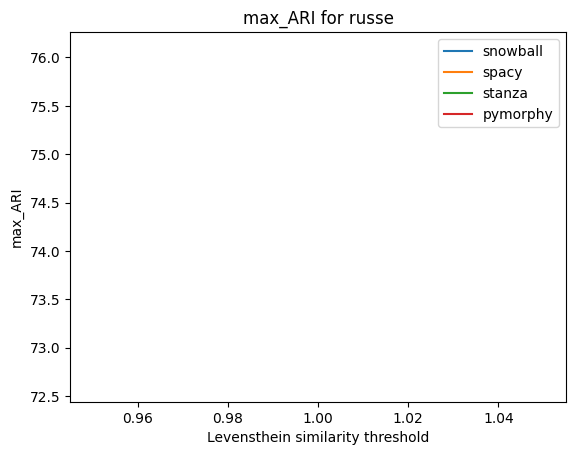

In [16]:
for name, values in d.items():
    values = sorted(values, key=lambda x: x[0])
    plt.plot([t[0] for t in values], [t[1] for t in values], label=name)
plt.ylabel(metric)
plt.title(f"{metric} for {dataset}")
plt.xlabel(f"Levensthein similarity threshold")
plt.legend()

In [61]:
import json
lemmas = json.load(open(r'D:\science\summer-wsi\SubstWSI_rombek\.lemma_cache\backup0704\stanza_word\lemma_clustering_0.7.json'))
print(len(set(lemmas.keys())), len(set(lemmas.values())))
lemmas = pd.Series(lemmas).reset_index()
print(lemmas[0].value_counts().sample(5))
lemmas[lemmas[0] == 'армировка']['index'].values

38292 10952
БНУ            1
итур           4
коэф           2
спокойствие    1
себежина       2
Name: 0, dtype: int64


array(['армировка', 'панировка', 'лакировка', 'маскировка', 'базировка',
       'маркировка', 'планировка', 'балансировка', 'базировать',
       'газировка'], dtype=object)

In [59]:

lemmas[lemmas[0] == 'раработка']['index'].values

array(['раработка', 'надработка', 'винаработка', 'расработка',
       'разработка', 'жеработка', 'минработка', 'тыработка', 'гоработка',
       'пораработка', 'переработка', 'допработка', 'доработка',
       'изработка', 'работка', 'выходаработка', 'будуработка',
       'сверхработка', 'приработка', 'своеработка', 'съработка',
       'давработка', 'посеработка', 'поработка', 'гиработка', 'айработка',
       'зработка', 'наработка', 'добаработка', 'подработка',
       'терпработка', 'преработка', 'опработка', 'выработка', 'работалка',
       'проработка', 'работека', 'соработка', 'порработка', 'обработка',
       'отработка', 'профработка', 'сработка', 'заработка'], dtype=object)

In [14]:
salaries = list(range(121, 141))
for sasha in range(len(salaries)):
    check = 0
    c = 0
    for p1 in range(len(salaries)):
        for p2 in range(p1+1, len(salaries)):
            if p1 != sasha and p2 != sasha and p1 != p2:
                if abs(salaries[p1] - salaries[p2]) <= 8:
                    check += 1
                c += 1
    if check == 115:
        print(sasha, salaries[sasha])

1 122
18 139


In [7]:
len(salaries)

20

In [10]:
19*18/2

171.0

In [16]:
from tqdm.notebook import tqdm
count = 0
for a in tqdm(range(1, 1_000_000)):
    for b in range(1, 1_000):
        if a*a + b == a * (999 - b):
            print(a, b)
            count += 1

print(count)

  0%|          | 0/999999 [00:00<?, ?it/s]

1 499
3 747
4 796
7 868
9 891
19 931
24 936
39 936
49 931
99 891
124 868
199 796
249 747
499 499
14


In [17]:
122+139

261

In [34]:
import fractions
import numpy as np
from operator import mul
from functools import reduce # python3 compatibility

res = fractions.Fraction(0, 1)
for k in range(2, 34):

    denom = [34 - i for i in range(k)]
    neg_roll = [34 - i - 17 for i in range(k-2)]
    frac = fractions.Fraction(numerator=reduce(mul, neg_roll, 1) * 7 * (k-1) * 10, denominator=reduce(mul, denom, 1))
    res += frac
    print(f"{k=} {denom=} {reduce(mul, denom, 1)=} {neg_roll=} {reduce(mul, neg_roll, 1)=} {frac=}")
res

k=2 denom=[34, 33] reduce(mul, denom, 1)=1122 neg_roll=[] reduce(mul, neg_roll, 1)=1 frac=Fraction(35, 561)
k=3 denom=[34, 33, 32] reduce(mul, denom, 1)=35904 neg_roll=[17] reduce(mul, neg_roll, 1)=17 frac=Fraction(35, 528)
k=4 denom=[34, 33, 32, 31] reduce(mul, denom, 1)=1113024 neg_roll=[17, 16] reduce(mul, neg_roll, 1)=272 frac=Fraction(35, 682)
k=5 denom=[34, 33, 32, 31, 30] reduce(mul, denom, 1)=33390720 neg_roll=[17, 16, 15] reduce(mul, neg_roll, 1)=4080 frac=Fraction(35, 1023)
k=6 denom=[34, 33, 32, 31, 30, 29] reduce(mul, denom, 1)=968330880 neg_roll=[17, 16, 15, 14] reduce(mul, neg_roll, 1)=57120 frac=Fraction(1225, 59334)
k=7 denom=[34, 33, 32, 31, 30, 29, 28] reduce(mul, denom, 1)=27113264640 neg_roll=[17, 16, 15, 14, 13] reduce(mul, neg_roll, 1)=742560 frac=Fraction(455, 39556)
k=8 denom=[34, 33, 32, 31, 30, 29, 28, 27] reduce(mul, denom, 1)=732058145280 neg_roll=[17, 16, 15, 14, 13, 12] reduce(mul, neg_roll, 1)=8910720 frac=Fraction(3185, 534006)
k=9 denom=[34, 33, 32, 31,

Fraction(35, 136)

In [35]:
fractions.Fraction(7, 34) * fractions.Fraction(10, 33)

Fraction(35, 561)

In [36]:
fractions.Fraction(34-10-7, 34) * fractions.Fraction(7, 33) * 2 * fractions.Fraction(10, 32)

Fraction(35, 528)

In [39]:
import math
a = [1, 1]
gcds = [1, 1]


for n in range(2, 100):
    a.append(a[-1] + a[-2] + math.gcd(a[-1], a[-2]))
    gcds.append(math.gcd(a[-1], a[-2]))
a

[1,
 1,
 3,
 5,
 9,
 15,
 27,
 45,
 81,
 135,
 243,
 405,
 729,
 1215,
 2187,
 3645,
 6561,
 10935,
 19683,
 32805,
 59049,
 98415,
 177147,
 295245,
 531441,
 885735,
 1594323,
 2657205,
 4782969,
 7971615,
 14348907,
 23914845,
 43046721,
 71744535,
 129140163,
 215233605,
 387420489,
 645700815,
 1162261467,
 1937102445,
 3486784401,
 5811307335,
 10460353203,
 17433922005,
 31381059609,
 52301766015,
 94143178827,
 156905298045,
 282429536481,
 470715894135,
 847288609443,
 1412147682405,
 2541865828329,
 4236443047215,
 7625597484987,
 12709329141645,
 22876792454961,
 38127987424935,
 68630377364883,
 114383962274805,
 205891132094649,
 343151886824415,
 617673396283947,
 1029455660473245,
 1853020188851841,
 3088366981419735,
 5559060566555523,
 9265100944259205,
 16677181699666569,
 27795302832777615,
 50031545098999707,
 83385908498332845,
 150094635296999121,
 250157725494998535,
 450283905890997363,
 750473176484995605,
 1350851717672992089,
 2251419529454986815,
 4052555153

In [54]:
324/12

27.0

In [58]:
s = 0
for k in range(1, 40):
    s +=  1/(a[k+1] - a[k])
    print(s)

0.5
1.0
1.25
1.4166666666666667
1.5
1.5555555555555556
1.5833333333333333
1.6018518518518519
1.6111111111111112
1.617283950617284
1.6203703703703705
1.6224279835390947
1.623456790123457
1.6241426611796983
1.6244855967078191
1.624714220393233
1.62482853223594
1.6249047401310779
1.6249428440786469
1.6249682467103594
1.6249809480262158
1.62498941557012
1.6249936493420722
1.624996471856707
1.6249978831140244
1.624998823952236
1.6249992943713418
1.624999607984079
1.6249997647904475
1.6249998693280265
1.624999921596816
1.6249999564426758
1.6249999738656056
1.624999985480892
1.6249999912885353
1.6249999951602976
1.6249999970961786
1.624999998386766
1.6249999990320596


In [56]:
for k in range(1, 40):
    print( a[k+1] - a[k], a[k+1], a[k])

2 3 1
2 5 3
4 9 5
6 15 9
12 27 15
18 45 27
36 81 45
54 135 81
108 243 135
162 405 243
324 729 405
486 1215 729
972 2187 1215
1458 3645 2187
2916 6561 3645
4374 10935 6561
8748 19683 10935
13122 32805 19683
26244 59049 32805
39366 98415 59049
78732 177147 98415
118098 295245 177147
236196 531441 295245
354294 885735 531441
708588 1594323 885735
1062882 2657205 1594323
2125764 4782969 2657205
3188646 7971615 4782969
6377292 14348907 7971615
9565938 23914845 14348907
19131876 43046721 23914845
28697814 71744535 43046721
57395628 129140163 71744535
86093442 215233605 129140163
172186884 387420489 215233605
258280326 645700815 387420489
516560652 1162261467 645700815
774840978 1937102445 1162261467
1549681956 3486784401 1937102445


In [71]:
1/100**2

0.0001

In [72]:
probas = np.array([1/(2+i)**2 for i in range(99)])
probas

array([2.50000000e-01, 1.11111111e-01, 6.25000000e-02, 4.00000000e-02,
       2.77777778e-02, 2.04081633e-02, 1.56250000e-02, 1.23456790e-02,
       1.00000000e-02, 8.26446281e-03, 6.94444444e-03, 5.91715976e-03,
       5.10204082e-03, 4.44444444e-03, 3.90625000e-03, 3.46020761e-03,
       3.08641975e-03, 2.77008310e-03, 2.50000000e-03, 2.26757370e-03,
       2.06611570e-03, 1.89035917e-03, 1.73611111e-03, 1.60000000e-03,
       1.47928994e-03, 1.37174211e-03, 1.27551020e-03, 1.18906064e-03,
       1.11111111e-03, 1.04058273e-03, 9.76562500e-04, 9.18273646e-04,
       8.65051903e-04, 8.16326531e-04, 7.71604938e-04, 7.30460190e-04,
       6.92520776e-04, 6.57462196e-04, 6.25000000e-04, 5.94883998e-04,
       5.66893424e-04, 5.40832883e-04, 5.16528926e-04, 4.93827160e-04,
       4.72589792e-04, 4.52693526e-04, 4.34027778e-04, 4.16493128e-04,
       4.00000000e-04, 3.84467512e-04, 3.69822485e-04, 3.55998576e-04,
       3.42935528e-04, 3.30578512e-04, 3.18877551e-04, 3.07787011e-04,
      

In [122]:
import joblib

def trial():
    Ks = []
    for trial in tqdm(range(10_000)):
        passed = np.full(99, 0)
        K = 0
        while not passed.all():
            sample = np.full(99, 0)
            for k in range(99):
                sample[k] = np.random.choice([1, 0], p=[1-probas[k], probas[k]])
            passed = passed | sample
            K += 1
        Ks.append(K)
    print(np.mean(Ks))
    return np.mean(Ks)

trials2 = joblib.Parallel(20)(joblib.delayed(trial)() for t in tqdm(range(250)))
trials2

  0%|          | 0/250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [115]:
trials = np.concatenate([trials, trials2])

In [116]:
len(trials)

1500

<Axes: ylabel='Count'>

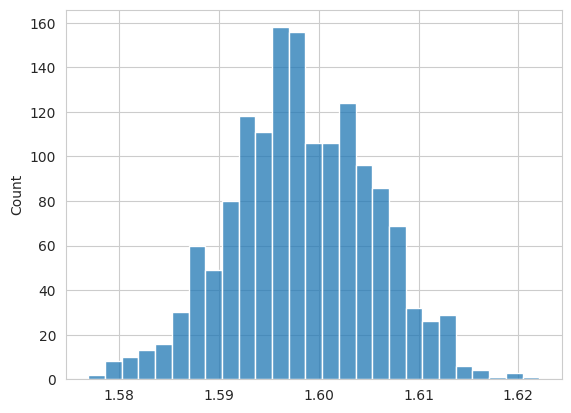

In [117]:
import seaborn as sns

sns.histplot(trials)

In [121]:
np.mean(trials)

1.5983179333333337

In [120]:
np.mean([np.mean(np.random.choice(trials, 250)) for _ in range(1000)])

1.5983218200000002

In [124]:
(probas*(1 - probas))

array([1.87500000e-01, 9.87654321e-02, 5.85937500e-02, 3.84000000e-02,
       2.70061728e-02, 1.99916701e-02, 1.53808594e-02, 1.21932632e-02,
       9.90000000e-03, 8.19616146e-03, 6.89621914e-03, 5.88214698e-03,
       5.07601000e-03, 4.42469136e-03, 3.89099121e-03, 3.44823458e-03,
       3.07689377e-03, 2.76240974e-03, 2.49375000e-03, 2.26243181e-03,
       2.06184687e-03, 1.88678571e-03, 1.73309703e-03, 1.59744000e-03,
       1.47710164e-03, 1.36986044e-03, 1.27388328e-03, 1.18764678e-03,
       1.10987654e-03, 1.03949991e-03, 9.75608826e-04, 9.17430419e-04,
       8.64303588e-04, 8.15660142e-04, 7.71009564e-04, 7.29926618e-04,
       6.92041191e-04, 6.57029939e-04, 6.24609375e-04, 5.94530111e-04,
       5.66572056e-04, 5.40540382e-04, 5.16262123e-04, 4.93583295e-04,
       4.72366451e-04, 4.52488595e-04, 4.33839398e-04, 4.16319661e-04,
       3.99840000e-04, 3.84319697e-04, 3.69685717e-04, 3.55871841e-04,
       3.42817923e-04, 3.30469230e-04, 3.18775868e-04, 3.07692279e-04,
      

In [27]:
from bisect import insort

arr = [3, 2, 4, 1, 5]
arr2 = [1, 2, 3, 4, 5]

def check(n, arr, arr_target):
    for i in range(n):
        if arr[i] != arr2[i]:
            k = i
            break
    else:
        return False # identical arrays

    a1 = []
    a2 = []
    for i in range(k, n):
        insort(a1, arr[i])
        insort(a2, arr_target[i])
        if a1 == a2:
            if arr[i+1:] == arr_target[i+1:]:
                return True
    return False

In [33]:
import numpy as np

for _ in range(50):
    length, top_a = np.random.randint(1, 25, size=2)
    shuffle_start, shuffle = np.random.randint(0, length+1, size=2)
    arr = list(np.random.randint(1, 1 + top_a, size=length))
    subset = arr[shuffle_start:shuffle_start+shuffle]
    subset = np.sort(subset)
    arr2 = arr[:shuffle_start] + list(subset) + arr[shuffle_start+shuffle:]
    print(arr)
    print(arr2)
    assert arr == arr2 or check(length, arr, arr2)


[14, 20, 3, 15, 3, 21, 16, 10, 9, 21, 22, 3]
[14, 20, 3, 15, 3, 10, 16, 21, 9, 21, 22, 3]
[5, 4, 6, 4, 6, 2, 2, 3, 7, 5, 4, 7, 2, 7, 1, 3, 7]
[5, 4, 6, 4, 6, 2, 2, 3, 7, 5, 4, 7, 2, 7, 1, 3, 7]
[10, 4, 8, 6, 12, 2, 4, 13, 4, 1, 9]
[1, 2, 4, 4, 4, 6, 8, 9, 10, 12, 13]
[9, 8, 11, 13, 11, 3, 7, 11, 13, 16, 1, 4, 7, 1, 5]
[9, 8, 11, 13, 11, 3, 7, 1, 1, 4, 5, 7, 11, 13, 16]
[6, 12, 19, 8, 12, 8, 15, 1, 16, 15, 14, 10, 4, 13, 14, 3]
[6, 12, 19, 1, 8, 8, 12, 15, 16, 15, 14, 10, 4, 13, 14, 3]
[7, 6, 7, 5, 5, 8]
[5, 5, 6, 7, 7, 8]
[9, 14, 10, 1, 2, 10, 4, 14, 10, 10, 2, 5, 7, 11, 9, 7, 8, 11]
[9, 14, 10, 1, 2, 10, 4, 14, 10, 10, 2, 5, 7, 7, 8, 9, 11, 11]
[9, 8, 3, 3, 9, 2, 4, 6, 7, 4, 8, 7, 6, 3, 3, 2, 2, 8, 3, 6]
[9, 8, 3, 3, 9, 2, 4, 6, 7, 4, 8, 7, 6, 2, 2, 3, 3, 8, 3, 6]
[2, 2, 9, 2, 23, 20, 1, 10, 14, 11]
[2, 2, 9, 2, 23, 1, 10, 11, 14, 20]
[5, 3]
[5, 3]
[1, 3, 3, 4, 3, 3, 1, 3, 4, 2, 4, 4, 2, 4, 4, 4, 1, 2, 2]
[1, 3, 3, 4, 3, 3, 1, 3, 4, 2, 4, 4, 2, 4, 4, 4, 1, 2, 2]
[5]
[5]
[12, 10, 8, 8,

In [31]:
from bisect import insort

n = int(5)
arr = [1, 4, 2, 2, 4]
arr2 = [1, 4, 4, 2, 2]

def check(n, arr, arr_target):
    for i in range(n):
        if arr[i] != arr_target[i]:
            k = i
            break
    else:
        return True # identical arrays
    print(k)
    a1 = []
    for i in range(k, n):
        insort(a1, arr[i])
        print(a1, arr_target[k:i+1])
        if a1 == arr_target[k:i+1]:
            if arr[i+1:] == arr_target[i+1:]:
                return True
    return False

res = check(n, arr, arr2)
if res:
    print('YES')
else:
    print('NO')

2
[2] [4]
[2, 2] [4, 2]
[2, 2, 4] [4, 2, 2]
NO


In [32]:
n = 6
arr = [5, 1, 2, 5, 3, 5]
arr2 = [5, 1, 2, 3, 5, 5]
check(n, arr, arr2)

3
[5] [3]
[3, 5] [3, 5]


True

In [33]:
check(3,
[4, 1, 2,],
[1, 4, 7,]
      )

0
[4] [1]
[1, 4] [1, 4]
[1, 2, 4] [1, 4, 7]


False

In [34]:
check(1,
[7],
[7]
      )

True

In [35]:
check(7,
[4, 4, 1, 7, 5, 3, 8],
[4, 1, 4, 5, 7, 3, 8]
      )

1
[4] [1]
[1, 4] [1, 4]
[1, 4, 7] [1, 4, 5]
[1, 4, 5, 7] [1, 4, 5, 7]


True